# Neo-Hookean hyperelasticity: clamped beam under end traction

Demonstrates `HyperelasticResidual`/`HyperelasticJacobian`/`HyperelasticResidualNeumann`
from `FESolid2D` (isochoric-volumetric split Neo-Hookean, plane strain) on a beam-like
domain: **clamped** (`u=0`) on the left edge, a constant **traction** pulling on the
right edge, with the top and bottom left free (natural/zero-traction).

Uses load-stepping (ramping the traction up over a few Newton solves, using each step's
solution as the next step's initial guess) since a single large jump in load can fail to
converge for a nonlinear hyperelastic problem.

Requires `FESolid2D` to be `dev`'d into your environment: `] dev <path-to-fe-demo>`,
plus `NLsolve` and `Plots`.

In [ ]:
using FESolid2D
using LinearAlgebra
using NLsolve
using Plots

default(linewidth=2)

## Mesh, material, and boundary conditions

In [ ]:
P, Q, num_comp, Qmode = 2, 2, 2, "GAUSS"
Bx = FEBasis(2, Q, 2, Qmode)
Bu = FEBasis(P, Q, num_comp, Qmode)

nx, ny, aspect_ratio = 20, 5, 4   # domain: x in [0,1], y in [0, 1/aspect_ratio]
xc, yc = GetCoordMesh("uniform", nx, ny, aspect_ratio)
Ind = FEIndices(P, num_comp, nx, ny)

lambda, mu = 1.0, 1.0

# Clamp: u = 0 on the left edge (both components)
bc_idx = GetDirichletBCsIndex(num_comp, Ind, (:left,))
u_bc = zeros(length(bc_idx))

# Traction: pull in +x on the right edge; top/bottom stay natural (free)
Fx = FEFaceIndices(P, num_comp, nx, ny, Ind, "right")
t0 = 1.2
t_right(x, y) = [t0 .* ones(length(x)); zeros(length(x))]
Ft = GetTractionGlobal(xc, yc, Fx, Ind, Bu, t_right)

f_zero(lambda, mu, x, y) = zeros(2 * length(x)) # no body force

## Load-stepping Newton solve

In [ ]:
u_dof = num_comp * maximum(Ind.idx_u)
u = zeros(u_dof)
nsteps = 6
for s = 1:nsteps
    frac = s / nsteps
    println("step $s/$nsteps (load frac=$(round(frac, digits=2))):")
    result = nlsolve(uu -> HyperelasticResidualNeumann(lambda, mu, uu, xc, yc, Ind, Bx, Bu, f_zero, bc_idx, u_bc, frac .* Ft),
        uu -> HyperelasticJacobian(lambda, mu, uu, xc, yc, Ind, Bx, Bu, bc_idx), u; method=:newton, show_trace=true)
    global u = result.zero
end
@show maximum(abs.(u));

step 1/6 (load frac=0.17):
Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     1.000000e-02              NaN
     1     7.610081e-04     2.395309e-01
     2     5.168304e-06     1.825364e-03
     3     2.312341e-10     7.983675e-08
step 2/6 (load frac=0.33):
Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     1.000000e-02              NaN
     1     8.379125e-04     3.353564e-01
     2     6.406726e-06     2.993631e-03
     3     3.978381e-10     1.770229e-07
step 3/6 (load frac=0.5):
Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     1.000000e-02              NaN
     1     9.236735e-04     4.818945e-01
     2     7.715829e-06     4.940753e-03
     3     6.608146e-10     3.891230e-07
step 4/6 (load frac=0.67):
Iter     f(x) inf-norm    Step 2-norm 
------   --------------   --------------
     0     1.000000e-02              NaN
     1     1.013141e-03     7.091789e-01

## Visualize: undeformed vs. deformed mesh

For `P=2` the solution nodes coincide exactly with the geometry corner nodes, so
`xc,yc` index the same nodes as `u`.

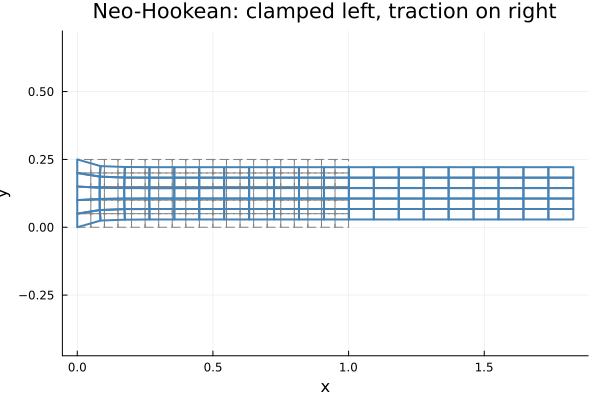

In [ ]:
num_nodes = maximum(Ind.idx_u)
xdef = xc .+ u[1:num_nodes]
ydef = yc .+ u[num_nodes+1:end]

function plot_mesh!(p, x, y, idx_x; kwargs...)
    order = [1, 2, 4, 3, 1]
    for e in 1:size(idx_x, 2)
        plot!(p, x[idx_x[order, e]], y[idx_x[order, e]]; legend=false, kwargs...)
    end
    return p
end

p = plot(aspect_ratio=:equal, xlabel="x", ylabel="y", title="Neo-Hookean: clamped left, traction on right")
plot_mesh!(p, xc, yc, Ind.idx_x, color=:gray, linestyle=:dash, linewidth=1)
plot_mesh!(p, xdef, ydef, Ind.idx_x, color=:steelblue, linewidth=2)
p